# 02 · Descripción, visualización y patrones

**Edición docente · 8 de octubre de 2026 · Fundamentos de Business Analytics**

**Núcleo U2 / RA2 · CE 2.1–2.5 · 120–150 minutos.**
Aprenderás a describir centro, dispersión, posición y forma; elegir gráficos; reconocer tendencias,
asociaciones y agrupamientos; y comunicar patrones con denominadores y límites explícitos.

**Cómo trabajar:** ejecuta desde la primera celda. En cada simulador formula primero una predicción,
cambia un parámetro y justifica la diferencia. Los datos son casos docentes del repositorio o
simulaciones identificadas; no permiten inferir resultados de empresas reales.

Los controles requieren JupyterLab con `ipywidgets` y un kernel activo; las salidas guardadas permiten
leer los ejemplos sin ejecutar. Las funciones también pueden llamarse directamente, con lo que
el ejercicio sigue siendo utilizable si el visor no muestra widgets.

[Guía maestra](../guia_maestra_ba.html) · [Manual científico](../material_propio/FBA_manual_cientifico.pdf)

### Antes de ejecutar

Núcleo · 60–90 min orientativos.

**Objetivo:** Elegir un resumen y un gráfico coherentes con la pregunta y el denominador.

**Preparación:** Ficha del módulo 01; media, mediana y tipo de variable.

**Ejemplo de referencia:** Comparar ingresos por producto y evolución mensual sin atribuir causalidad a una línea.

**Práctica:** Filtrar un segmento y comprobar si cambia el mensaje al mantener el mismo denominador.

**Criterio de logro:** Presentar un gráfico con unidad, período, población y una interpretación verificable.

[Guía y secuencia](../guia_maestra_ba.html#ruta-aprendizaje) · [Fundamento del manual](../material_propio/FBA_manual_cientifico.html#sec-visualizacion)

In [1]:
from pathlib import Path
import sys
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "_transversal" / "datos").is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError("Abra Jupyter desde el repositorio completo o una subcarpeta.")
CURSO = RAIZ / "01_Fundamentos_Business_Analytics"
sys.path.insert(0, str(CURSO / "reproducibilidad"))
from fba_recursos import ventas, resumen_ventas, pregunta, DATOS, SEMILLA
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, Markdown
%matplotlib inline
plt.rcParams.update({"figure.figsize": (8, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .18})
pd.set_option("display.max_columns", 14)
df = ventas()
print(f"Python {sys.version.split()[0]} · pandas {pd.__version__} · {len(df)} transacciones")

Python 3.12.13 · pandas 3.0.6 · 180 transacciones


<a id="descriptiva"></a>

## Estadística descriptiva

La media usa todos los valores y responde al reparto uniforme del total. La mediana localiza el centro
del orden y suele ser más estable ante extremos. La desviación estándar muestral divide por $n-1$;
la varianza poblacional descriptiva de la colección divide por $n$. Son preguntas distintas.
El rango intercuartílico (RIC) resume el 50% central. Los cuantiles de este laboratorio usan interpolación
lineal, la misma convención implementada en la guía HTML.

El coeficiente de variación $s/\bar x$ se interpreta para una escala de razón y media positiva suficientemente
alejada de cero. La asimetría y el exceso de curtosis complementan el gráfico; no lo reemplazan.

In [2]:
x = df.Monto.astype(float)
resumen = pd.Series({"n":x.size,"media":x.mean(),"mediana":x.median(),
 "sd_muestral":x.std(ddof=1),"sd_poblacional":x.std(ddof=0),
 "Q1":x.quantile(.25),"Q3":x.quantile(.75),"RIC":x.quantile(.75)-x.quantile(.25),
 "asimetria_ajustada":x.skew(),"exceso_curtosis_ajustado":x.kurt(),
 "CV":x.std(ddof=1)/x.mean()})
display(resumen)
assert np.isclose(x.var(ddof=1), ((x-x.mean())**2).sum()/(len(x)-1))
print("Moda(s) observadas:", x.mode().tolist())

n                           1.800000e+02
media                       1.022346e+06
mediana                     8.999800e+05
sd_muestral                 6.515521e+05
sd_poblacional              6.497397e+05
Q1                          4.499900e+05
Q3                          1.487212e+06
RIC                         1.037222e+06
asimetria_ajustada          8.384231e-01
exceso_curtosis_ajustado    4.770966e-02
CV                          6.373108e-01
dtype: float64

Moda(s) observadas: [1169970.0]


### Experimento controlado: sensibilidad a un extremo

El control añade una observación a una muestra didáctica. Es un experimento numérico sobre un estimador,
no una instrucción para descartar transacciones de gran monto. Observa simultáneamente centro y dispersión.
Cuando media y mediana coinciden no queda probada la simetría: una distribución multimodal puede compartirlas.

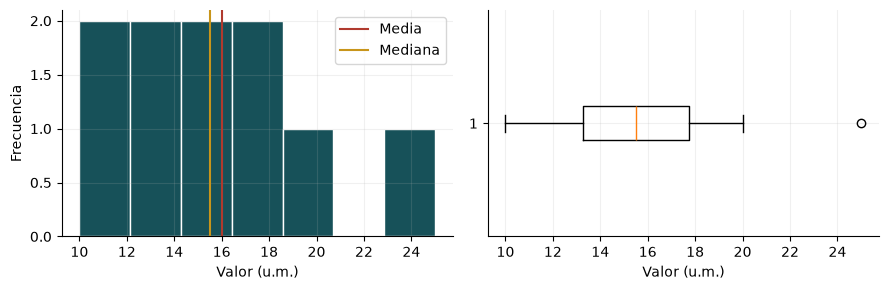

Media=16.00; mediana=15.50; RIC=4.50


interactive(children=(FloatSlider(value=25.0, description='valor', max=150.0, step=5.0), Output()), _dom_class…

In [3]:
def efecto_extremo(valor=25.):
    muestra = np.array([10,12,13,14,15,16,17,18,20,float(valor)])
    q1,q3 = np.quantile(muestra,[.25,.75])
    fig, axes = plt.subplots(1,2,figsize=(9,3))
    axes[0].hist(muestra,bins=7,color="#175159",edgecolor="white")
    axes[0].axvline(muestra.mean(),color="#b03a2e",label="Media")
    axes[0].axvline(np.median(muestra),color="#c8951b",label="Mediana")
    axes[0].set(xlabel="Valor (u.m.)",ylabel="Frecuencia"); axes[0].legend()
    axes[1].boxplot(muestra,orientation="horizontal"); axes[1].set_xlabel("Valor (u.m.)")
    plt.tight_layout(); plt.show()
    print(f"Media={muestra.mean():.2f}; mediana={np.median(muestra):.2f}; RIC={q3-q1:.2f}")
    return muestra.mean(), np.median(muestra)

efecto_extremo(25)
widgets.interact(efecto_extremo,valor=widgets.FloatSlider(value=25,min=0,max=150,step=5));

<a id="visualizacion"></a>

## Visualizaciones según pregunta

Usa barras para categorías y líneas para tiempo ordenado. Un histograma agrupa valores numéricos
en intervalos; modificar sus bordes puede cambiar la percepción. Un boxplot resume posición y
valores fuera de las cercas de 1,5 RIC; esos puntos son señales para investigar, no errores demostrados.
El mapa de calor representa una tabla con color, por lo que exige unidades y escala legibles.

Las barras de ingresos comienzan en cero. En una serie temporal se puede usar otro rango si se
declara y no se exagera el cambio. Evita ordenar meses alfabéticamente o confundir ausencia de datos con cero.

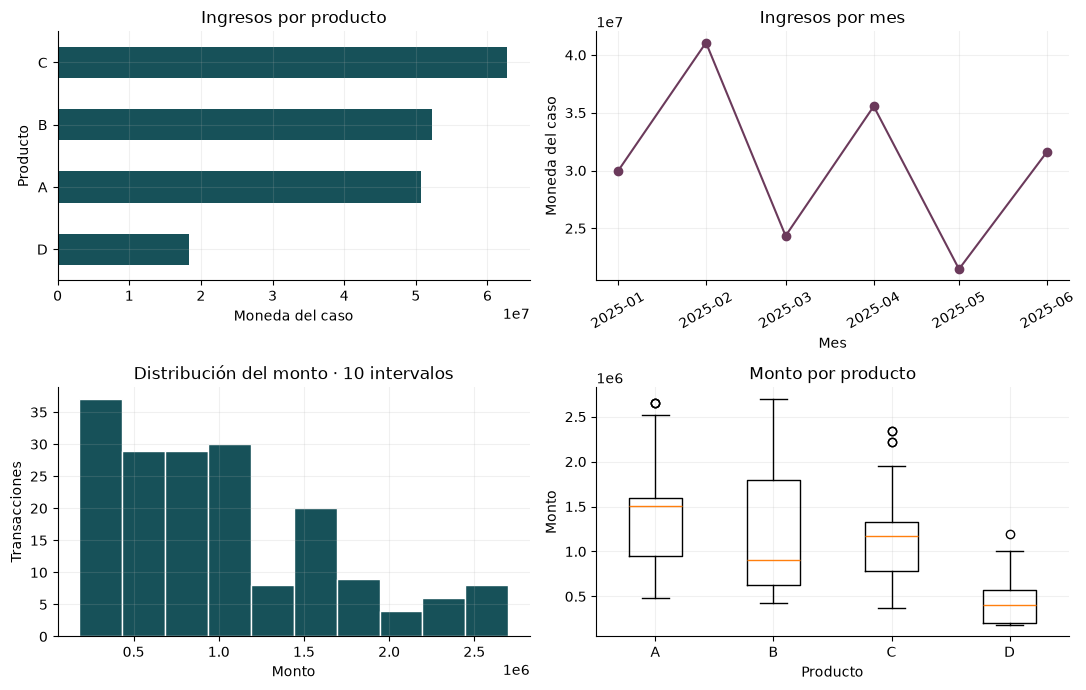

transacciones        1.800000e+02
unidades             4.730000e+02
ingreso              1.840223e+08
ticket_medio         1.022346e+06
precio_por_unidad    3.890534e+05
dtype: float64

interactive(children=(Dropdown(description='region', options=('Todas', 'Centro', 'Norte', 'Sur'), value='Todas…

In [4]:
def tablero_visual(region="Todas", bins=10):
    d = df if region=="Todas" else df.loc[df.Region.eq(region)]
    fig, axes = plt.subplots(2,2,figsize=(11,7))
    d.groupby("Producto").Monto.sum().sort_values().plot.barh(ax=axes[0,0],color="#175159")
    axes[0,0].set(title="Ingresos por producto",xlabel="Moneda del caso",ylabel="Producto")
    mensual=d.set_index("Fecha").Monto.resample("MS").sum(min_count=1)
    axes[0,1].plot(mensual.index,mensual.values,marker="o",color="#6b3a5b")
    axes[0,1].set(title="Ingresos por mes",ylabel="Moneda del caso",xlabel="Mes")
    axes[0,1].tick_params(axis="x",rotation=30)
    axes[1,0].hist(d.Monto,bins=bins,color="#175159",edgecolor="white")
    axes[1,0].set(title=f"Distribución del monto · {bins} intervalos",xlabel="Monto",ylabel="Transacciones")
    axes[1,1].boxplot([g.Monto.to_numpy() for _,g in d.groupby("Producto")],
                      tick_labels=[k for k,_ in d.groupby("Producto")])
    axes[1,1].set(title="Monto por producto",xlabel="Producto",ylabel="Monto")
    plt.tight_layout(); plt.show()
    display(pd.Series(resumen_ventas(d)))
    return mensual

tablero_visual()
widgets.interact(tablero_visual,region=["Todas",*sorted(df.Region.unique())],bins=(4,24,2));

<a id="relaciones"></a>

## Asociación, tendencia y límites

Pearson mide asociación lineal y requiere variabilidad en ambas variables. Spearman usa rangos y
detecta asociación monótona. Ninguna identifica por sí sola una causa. En QuillayMarket, el monto contiene
el producto `Unidades × Precio_Unitario`: su correlación con unidades incluye una relación contable.
No debe presentarse como estimación causal de vender una unidad adicional mediante una intervención.

Para mostrar que $r=0$ no implica independencia construimos $y=x^2$ sobre un dominio simétrico.
Luego agrupamos por producto antes de formular una hipótesis de negocio.

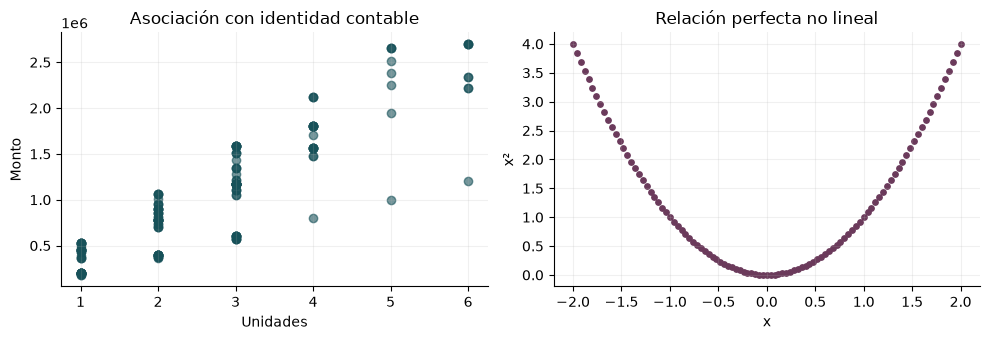

Pearson unidades/monto: 0.8924433104001149
Spearman unidades/monto: 0.8792004573675
Pearson x/x²: 1.3639926937433163e-16


In [5]:
from scipy.stats import spearmanr
curva_x=np.linspace(-2,2,101); curva_y=curva_x**2
fig, axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].scatter(df.Unidades,df.Monto,alpha=.6,color="#175159")
axes[0].set(xlabel="Unidades",ylabel="Monto",title="Asociación con identidad contable")
axes[1].scatter(curva_x,curva_y,s=15,color="#6b3a5b")
axes[1].set(xlabel="x",ylabel="x²",title="Relación perfecta no lineal")
plt.tight_layout(); plt.show()
print("Pearson unidades/monto:",df.Unidades.corr(df.Monto))
print("Spearman unidades/monto:",spearmanr(df.Unidades,df.Monto).statistic)
print("Pearson x/x²:",np.corrcoef(curva_x,curva_y)[0,1])
assert abs(np.corrcoef(curva_x,curva_y)[0,1]) < 1e-12

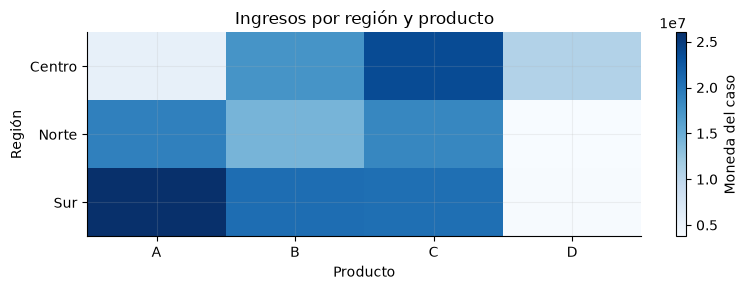

Producto,A,B,C,D
Region,,,,
Centro,5564890.0,17344610.0,23659380.0,10649460.0
Norte,19101630.0,14195680.0,18542520.0,3749810.0
Sur,26018500.0,20717530.0,20568460.0,3909800.0


In [6]:
tabla=df.pivot_table(index="Region",columns="Producto",values="Monto",aggfunc="sum",fill_value=0)
fig,ax=plt.subplots(figsize=(8,3))
im=ax.imshow(tabla.values,cmap="Blues",aspect="auto")
ax.set_xticks(range(len(tabla.columns)),tabla.columns)
ax.set_yticks(range(len(tabla.index)),tabla.index)
ax.set(title="Ingresos por región y producto",xlabel="Producto",ylabel="Región")
fig.colorbar(im,ax=ax,label="Moneda del caso")
plt.tight_layout();plt.show()
display(tabla)
assert np.isclose(tabla.to_numpy().sum(),df.Monto.sum())

### Denominadores y paradoja de agregación

Un canal puede tener una tasa agregada inferior aunque supere al otro dentro de cada segmento,
si atiende una mezcla distinta de clientes. La siguiente tabla es **sintética** y lo demuestra:
el canal A tiene 90% y 30%, frente a 80% y 20% del B; pero A concentra más casos difíciles.
No se concluye automáticamente que la comparación estratificada sea causal: también debe
justificarse qué variables se controlan y cómo se asignó el canal.

In [7]:
mezcla=pd.DataFrame({"canal":["A","A","B","B"],"segmento":["Fácil","Difícil"]*2,
                      "exitos":[9,27,72,2],"casos":[10,90,90,10]})
mezcla["tasa"]=mezcla.exitos/mezcla.casos
display(mezcla)
agregado=mezcla.groupby("canal")[["exitos","casos"]].sum()
agregado["tasa"]=agregado.exitos/agregado.casos
display(agregado)
assert agregado.loc["A","tasa"] < agregado.loc["B","tasa"]

,canal,segmento,exitos,casos,tasa
0,A,Fácil,9,10,0.9
1,A,Difícil,27,90,0.3
2,B,Fácil,72,90,0.8
3,B,Difícil,2,10,0.2


,exitos,casos,tasa
canal,,,
A,36,100,0.36
B,74,100,0.74


<a id="comunicacion-visual"></a>

## Comunicar un patrón

Usa la estructura **evidencia → interpretación → decisión condicionada**. Ejemplo:
«Este archivo registra mayor ingreso en el producto X durante el semestre. El total puede reflejar
precio o cantidad, por lo que revisaré ambas dimensiones antes de priorizar inventario. Propongo
validar margen, disponibilidad y demanda antes de cambiar compras». Completa X con el resultado,
no con una intuición previa. Seis meses no permiten demostrar estacionalidad anual.

**Ejercicios resueltos y de discusión**

1. Cambia el extremo de 25 a 150: la media sube de 16 a 28,5; la mediana permanece 15,5. El cambio
   describe sensibilidad, no prueba que la observación sea inválida.
2. Cambia los intervalos del histograma y documenta qué conclusiones se mantienen. El número
   de transacciones y el ingreso no cambian; la apariencia sí puede cambiar.
3. En la tabla sintética, A logra 36/100 y B 74/100. El promedio simple de tasas segmentadas
   omite el tamaño de los grupos. Reconstruye cada tasa con sus denominadores.
4. Presenta dos patrones del caso y una explicación alternativa para cada uno. Usa títulos
   informativos, unidades y el período de observación.

In [8]:
auto_02=pregunta("Un r cercano a cero permite afirmar que…",
    ["Las variables son independientes", "No hay una asociación lineal fuerte en esa muestra",
     "Ningún modelo puede relacionarlas"],1,
    "Una relación no lineal como y=x² puede coexistir con r≈0.")
assert np.isclose(np.mean([10,12,13,14,15,16,17,18,20,25]),16)
assert np.isclose(np.median([10,12,13,14,15,16,17,18,20,150]),15.5)
print("Comprobaciones del laboratorio 02: OK")

Comprobaciones del laboratorio 02: OK


### Referencias

[NIST: gráficos de dispersión](https://www.itl.nist.gov/div898/handbook/eda/section3/eda33q.htm)
y [asimetría y curtosis](https://www.itl.nist.gov/div898/handbook/eda/section3/eda35b.htm).
Las visualizaciones y contraejemplos de este laboratorio son construcciones docentes propias.